In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Activation
from keras.datasets.mnist import load_data

import tensorflow as tf
import matplotlib.pyplot as plt

import json
import os
import shutil
import random
import cv2
import pandas as pd
from matplotlib import pyplot as plt

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [ ]:
SEED_VALUE = 42
# Fix seed to make training deterministic.
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [ ]:
KAGGLE_PATH = "/root/.kaggle"
if os.path.exists(KAGGLE_PATH):
  !rm -r "$KAGGLE_PATH"

!mkdir "$KAGGLE_PATH"
!touch "$KAGGLE_PATH/kaggle.json"

# https://www.kaggle.com/
api_token = {"username":"Colab_Keras","key":"KGAT_6c5e3427714f0b3f5fe56de3de7aa623"}

with open(KAGGLE_PATH+'/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gpiosenka/musical-instruments-image-classification")

print("Path to dataset files:", path)

100%|██████████| 204M/204M [00:11<00:00, 18.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gpiosenka/musical-instruments-image-classification/versions/1


In [ ]:
import tarfile

archive_file_path = os.path.join(path, "EfficientNetB3-instruments-99.33.h5")

# Print the contents of the downloaded directory
print(f"Contents of the downloaded directory '{path}':")
!ls -F "{path}"

# The .h5 file is likely a pre-trained model, not an archive to be extracted.
# The actual image data is expected to be in the 'train', 'valid', and 'test' subdirectories.

print("Note: The file 'EfficientNetB3-instruments-99.33.h5' is likely a Keras model and not an archive of images.")
print(f"Images are expected to be found in subdirectories like '{path}/train/', '{path}/valid/', '{path}/test/'.")

Contents of the downloaded directory '/root/.cache/kagglehub/datasets/gpiosenka/musical-instruments-image-classification/versions/1':
'6 test samples'/		       instruments.csv		   test/
 class_dict.csv			       Musical_Instruments/	   train/
 EfficientNetB3-instruments-99.33.h5   NotMNIST_small_extracted/   valid/
Note: The file 'EfficientNetB3-instruments-99.33.h5' is likely a Keras model and not an archive of images.
Images are expected to be found in subdirectories like '/root/.cache/kagglehub/datasets/gpiosenka/musical-instruments-image-classification/versions/1/train/', '/root/.cache/kagglehub/datasets/gpiosenka/musical-instruments-image-classification/versions/1/valid/', '/root/.cache/kagglehub/datasets/gpiosenka/musical-instruments-image-classification/versions/1/test/'.


In [ ]:
import glob

# Store all the image paths in a list.
# The images are within the 'train', 'valid', and 'test' subdirectories of 'path'.
# I will search for common image formats like .jpg, .jpeg, and .png.
image_paths = []

for sub_dir in ['train', 'valid', 'test']:
    full_sub_dir_path = os.path.join(path, sub_dir)
    image_paths.extend(sorted(glob.glob(os.path.join(full_sub_dir_path, '**', '*.jpg'), recursive=True)))
    image_paths.extend(sorted(glob.glob(os.path.join(full_sub_dir_path, '**', '*.jpeg'), recursive=True)))
    image_paths.extend(sorted(glob.glob(os.path.join(full_sub_dir_path, '**', '*.png'), recursive=True)))

print(f"Found {len(image_paths)} images.")
# print(image_paths[:5]) # Print first 5 paths to verify

Found 5093 images.


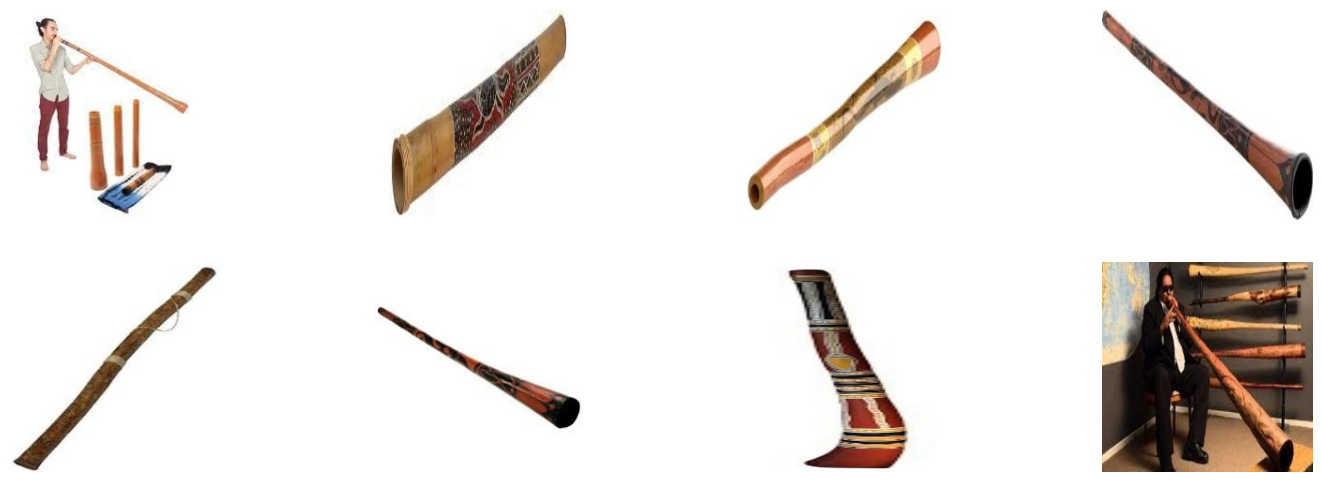

In [ ]:
plt.figure(figsize=(18, 6))
for idx, image_path in enumerate(image_paths[:8]): # Limit to first 8 images
    image = plt.imread(image_path)
    plt.subplot(2,4,idx+1)
    plt.imshow(image)
    plt.axis('off')

Model VGG is used for the musical instruments.

In [ ]:
model_vgg16        = tf.keras.applications.vgg16.VGG16()
model_resnet50     = tf.keras.applications.resnet50.ResNet50()
model_inception_v3 = tf.keras.applications.inception_v3.InceptionV3()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
print(model_vgg16.input_shape)
print(model_resnet50.input_shape)
print(model_inception_v3.input_shape)

(None, 224, 224, 3)
(None, 224, 224, 3)
(None, 299, 299, 3)


In [36]:
def process_images(model, image_paths, size, preprocess_input, display_top_k=False, top_k=2):

    # Get class labels from the generator for decoding predictions
    # Invert the dictionary to map index to class name
    if 'train_generator' in globals():
        idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
    else:
        # Fallback if train_generator is not available (e.g., initial VGG/ResNet tests)
        # This should ideally not happen after fine-tuning setup
        idx_to_class = None

    plt.figure(figsize=(20,7))
    for idx, image_path in enumerate(image_paths):

        # Read the image using TensorFlow.
        tf_image = tf.io.read_file(image_path);

        # Decode the above `tf_image` from a Bytes string to a numeric Tensor.
        decoded_image = tf.image.decode_image(tf_image);

        # Resize the image to the spatial size required by the model.
        image_resized = tf.image.resize(decoded_image, size);

        # Add a batch dimension to the first axis (required).
        image_batch = tf.expand_dims(image_resized, axis=0);

        # Pre-process the input image.
        image_batch = preprocess_input(image_batch);

        # Forward pass through the model to make predictions.
        preds = model.predict(image_batch);

        if idx_to_class is not None:
            # Get the top K predictions and their probabilities
            top_k_indices = tf.argsort(preds[0], direction='DESCENDING')[:top_k]
            top_k_probs = tf.gather(preds[0], top_k_indices)
            top_k_classes = [idx_to_class[i.numpy()] for i in top_k_indices]

            if display_top_k == True:
                print(f"Predictions for {os.path.basename(image_path)}:")
                for jdx in range(top_k):
                    print("Top {} predicted class:   Pr(Class={:20}) = {:5.2f}".format(
                        jdx + 1, top_k_classes[jdx], top_k_probs[jdx] * 100))
                print("\n")

            # Get the top 1 prediction for the title
            label = top_k_classes[0]
            score = top_k_probs[0] * 100
        else:
            # Fallback for models not using custom classes
            # This part will likely not be reached for the fine-tuned model
            decoded_preds = tf.keras.applications.imagenet_utils.decode_predictions(
                preds=preds,
                top=5
            )
            if display_top_k == True:
                for jdx in range(top_k):
                    print("Top {} predicted class:   Pr(Class={:20} [index={:4}]) = {:5.2f}".format(
                        jdx + 1, decoded_preds[0][jdx][1], jdx, decoded_preds[0][jdx][2] * 100))
            label = decoded_preds[0][0][1]
            score = decoded_preds[0][0][2] * 100

        plt.subplot(2,4,idx+1)
        # Ensure image is not float if it was decoded as such
        if decoded_image.dtype == tf.float32:
            decoded_image = tf.cast(decoded_image * 255, tf.uint8)
        plt.imshow(decoded_image)
        plt.axis('off')
        title = label + ' ' + str('{:.2f}%'.format(score))
        plt.title(title, fontsize=16)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


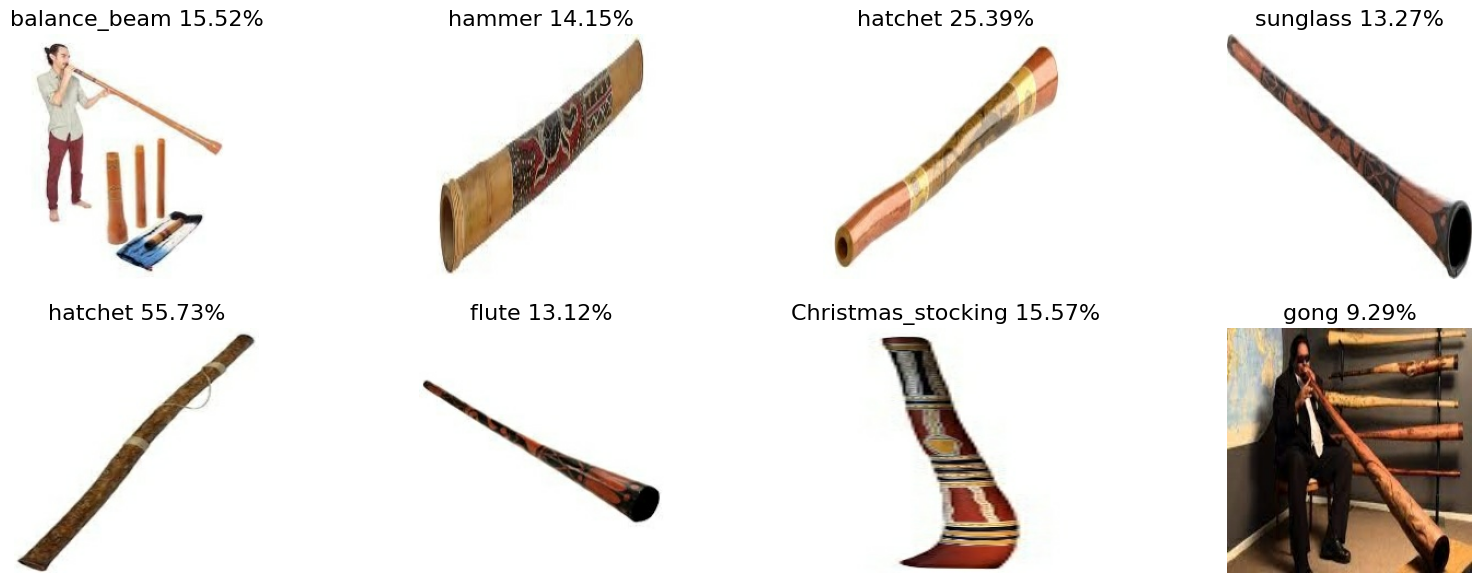

In [ ]:
model = model_vgg16
size = (224, 224)

preprocess_input = tf.keras.applications.vgg16.preprocess_input

# Limit the number of images passed to process_images to match the subplot grid size (2x4 = 8 images).
process_images(model, image_paths[:8], size, preprocess_input)

Model RESNET-50 is going to be used for the musical instruments pictures.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


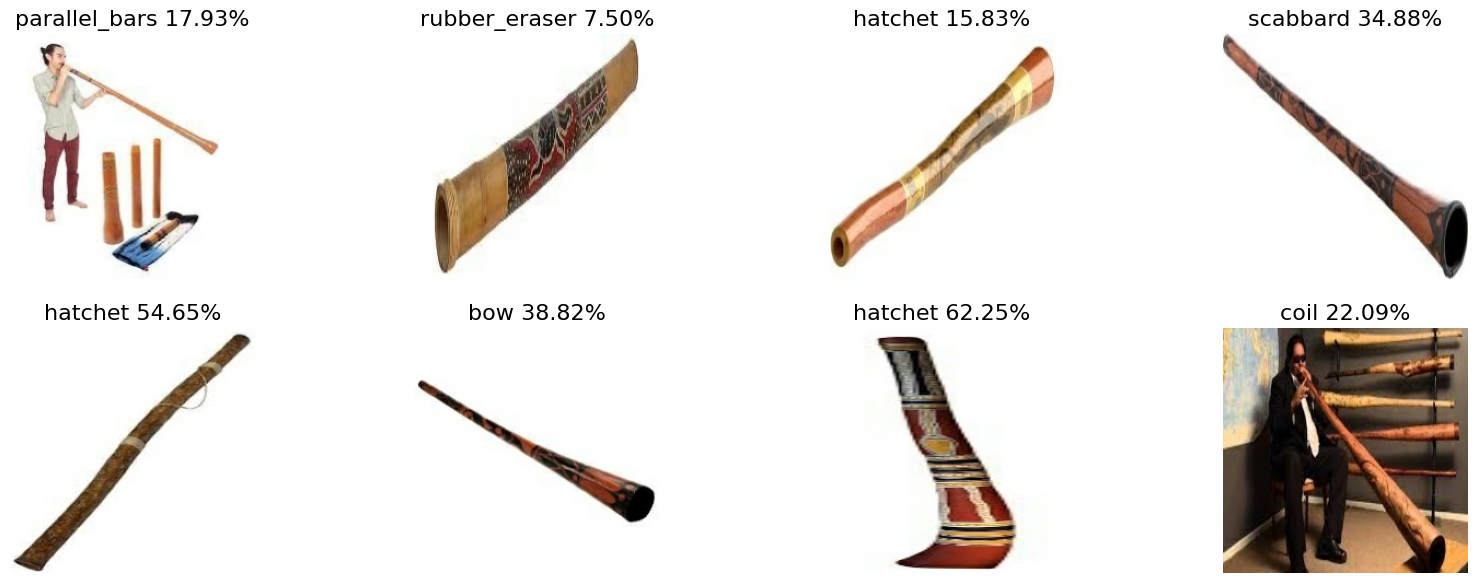

In [ ]:
model = model_resnet50
size = (224, 224)

preprocess_input = tf.keras.applications.resnet50.preprocess_input

process_images(model, image_paths[:8], size, preprocess_input)

Model Inception is going to be used for musical instruments.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Top 1 predicted class:   Pr(Class=parallel_bars        [index=   0]) = 48.34
Top 2 predicted class:   Pr(Class=balance_beam         [index=   1]) =  8.14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Top 1 predicted class:   Pr(Class=pole                 [index=   0]) = 64.54
Top 2 predicted class:   Pr(Class=hammer               [index=   1]) = 19.06
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
Top 1 predicted class:   Pr(Class=hammer               [index=   0]) = 35.05
Top 2 predicted class:   Pr(Class=bassoon              [index=   1]) = 18.58
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
Top 1 predicted class:   Pr(Class=hammer               [index=   0]) = 34.48
Top 2 predicted class:   Pr(Class=pole                 [index=   1]) =  9.04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Top 1 predicted class:   Pr(Class=bow                  [index=   0]) = 73.88
Top 2 predicted class:   Pr(Class=scabbard             [index=   1]) =  6.01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

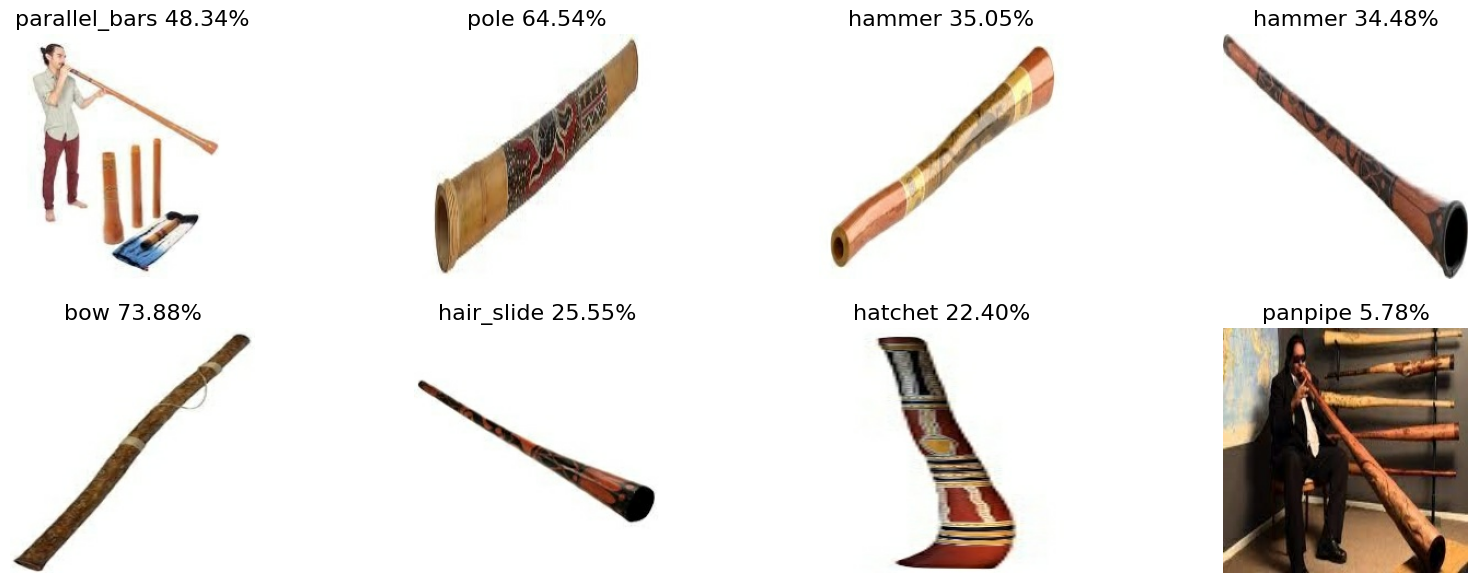

In [ ]:
model = model_inception_v3
size = (299, 299)

preprocess_input = tf.keras.applications.inception_v3.preprocess_input

process_images(model, image_paths[:8], size, preprocess_input, display_top_k=True)

In [ ]:
import pandas as pd
import os

# Extract labels from image paths
# The label is the name of the subdirectory directly under 'train', 'valid', or 'test'.
labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]

# Create a DataFrame
df_images = pd.DataFrame({'path': image_paths, 'label': labels})

print(f"Total images: {len(df_images)}")
print(f"Unique labels (instrument types): {df_images['label'].nunique()}")
display(df_images.head())


Total images: 5093
Unique labels (instrument types): 30


,path,label
0,/root/.cache/kagglehub/datasets/gpiosenka/musi...,Didgeridoo
1,/root/.cache/kagglehub/datasets/gpiosenka/musi...,Didgeridoo
2,/root/.cache/kagglehub/datasets/gpiosenka/musi...,Didgeridoo
3,/root/.cache/kagglehub/datasets/gpiosenka/musi...,Didgeridoo
4,/root/.cache/kagglehub/datasets/gpiosenka/musi...,Didgeridoo


Now, let's split the data into training, validation, and test sets. We'll use `train_test_split` twice to achieve this (e.g., 80% train, 10% validation, 10% test).

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and temporary (validation + test) sets
train_df, temp_df = train_test_split(df_images, test_size=0.2, stratify=df_images['label'], random_state=SEED_VALUE)

# Split temporary into validation and test sets
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED_VALUE)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

# Verify class distribution (optional)
print("\nTrain set class distribution:")
print(train_df['label'].value_counts(normalize=True).head())
print("\nValidation set class distribution:")
print(val_df['label'].value_counts(normalize=True).head())
print("\nTest set class distribution:")
print(test_df['label'].value_counts(normalize=True).head())


Train set size: 4074
Validation set size: 509
Test set size: 510

Train set class distribution:
label
Tambourine    0.055965
casaba        0.044674
sitar         0.044428
acordian      0.042955
clavichord    0.042464
Name: proportion, dtype: float64

Validation set class distribution:
label
Tambourine    0.055010
casaba        0.045187
clavichord    0.043222
acordian      0.043222
sitar         0.043222
Name: proportion, dtype: float64

Test set class distribution:
label
Tambourine    0.056863
casaba        0.045098
sitar         0.045098
Xylophone     0.043137
acordian      0.043137
Name: proportion, dtype: float64


Next, we'll create `ImageDataGenerator` instances for data augmentation and preprocessing. This will also convert our DataFrame to a format suitable for model training.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# InceptionV3 expects inputs scaled to the range [-1, 1]
preprocess_input_inception = tf.keras.applications.inception_v3.preprocess_input

IMAGE_SIZE = (299, 299) # InceptionV3 input size
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input_inception,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only preprocessing for validation and test data (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input_inception
)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED_VALUE
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED_VALUE
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED_VALUE,
    shuffle=False # Keep data in order for evaluation
)

# Get the number of classes from the generator
NUM_CLASSES = len(train_generator.class_indices)
print(f"Number of classes: {NUM_CLASSES}")

Found 4074 validated image filenames belonging to 30 classes.
Found 509 validated image filenames belonging to 30 classes.
Found 510 validated image filenames belonging to 30 classes.
Number of classes: 30


### Build the Fine-tuning Model

In [ ]:
# Load the InceptionV3 model, pre-trained on ImageNet, without its top classification layer
base_model = tf.keras.applications.InceptionV3(input_shape=IMAGE_SIZE + (3,), # (299, 299, 3)
                                             include_top=False,
                                             weights='imagenet')

# Freeze the base model to prevent its weights from being updated during the initial training phase
base_model.trainable = False

# Create a new model on top of the pre-trained base
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = base_model(inputs, training=False) # Keep base_model in inference mode when frozen
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x) # Additional dense layer
x = tf.keras.layers.Dropout(0.5)(x) # Dropout for regularization
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,867,262 (87.23 MB)

 Trainable params: 1,064,478 (4.06 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### Compile the Model

In [ ]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Train the Model

In [32]:
EPOCHS = 10 # You can adjust this number

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1301s 10s/step - accuracy: 0.9381 - loss: 0.2146 - val_accuracy: 0.9509 - val_loss: 0.1779
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1150s 9s/step - accuracy: 0.9367 - loss: 0.2032 - val_accuracy: 0.9509 - val_loss: 0.1640
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 854s 7s/step - accuracy: 0.9401 - loss: 0.1960 - val_accuracy: 0.9450 - val_loss: 0.1690
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 910s 7s/step - accuracy: 0.9492 - loss: 0.1846 - val_accuracy: 0.9548 - val_loss: 0.1618
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 997s 8s/step - accuracy: 0.9504 - loss: 0.1756 - val_accuracy: 0.9509 - val_loss: 0.1575
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 911s 7s/step - accuracy: 0.9514 - loss: 0.1689 - val_accuracy: 0.9509 - val_loss: 0.1539
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 923s 7s/step - accuracy: 0.9546 - loss: 0.1586 - val_accuracy: 0.9470 - val_loss: 0.1563
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 936s 7s/step - accuracy: 0.9497 - loss: 0.1550 - val_a

### Analyze Training History

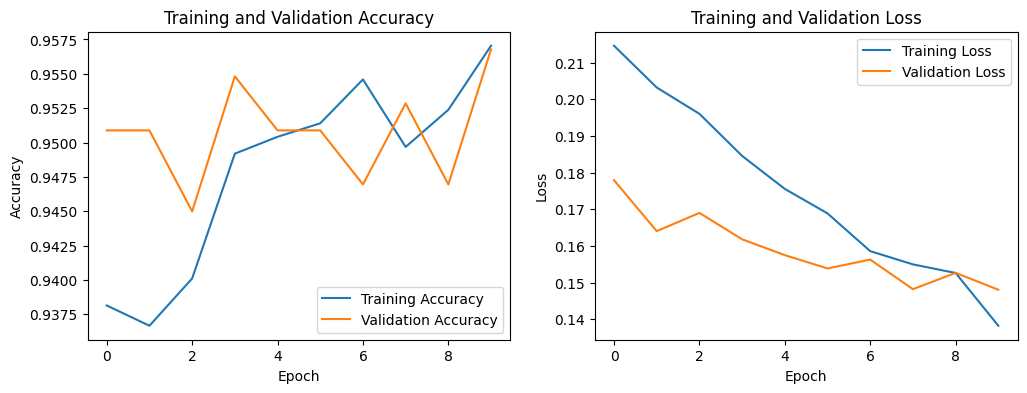

In [33]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_training_history(history)

### Visualize Predictions on Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
Predictions for 095.jpg:
Top 1 predicted class:   Pr(Class=dulcimer            ) = 84.62
Top 2 predicted class:   Pr(Class=castanets           ) =  6.41
Top 3 predicted class:   Pr(Class=guiro               ) =  4.95


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
Predictions for 029.jpg:
Top 1 predicted class:   Pr(Class=violin              ) = 100.00
Top 2 predicted class:   Pr(Class=dulcimer            ) =  0.00
Top 3 predicted class:   Pr(Class=castanets           ) =  0.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
Predictions for 057.jpg:
Top 1 predicted class:   Pr(Class=tuba                ) = 99.95
Top 2 predicted class:   Pr(Class=trombone            ) =  0.03
Top 3 predicted class:   Pr(Class=trumpet             ) =  0.02


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
Predictions for 064.jpg:
Top 1 predicted class:   Pr(Class=bongo drum          ) = 96.46
Top 2 predicted class:   Pr(Class=alphorn             ) =  1.45
Top 3 predicted class:   Pr(Class

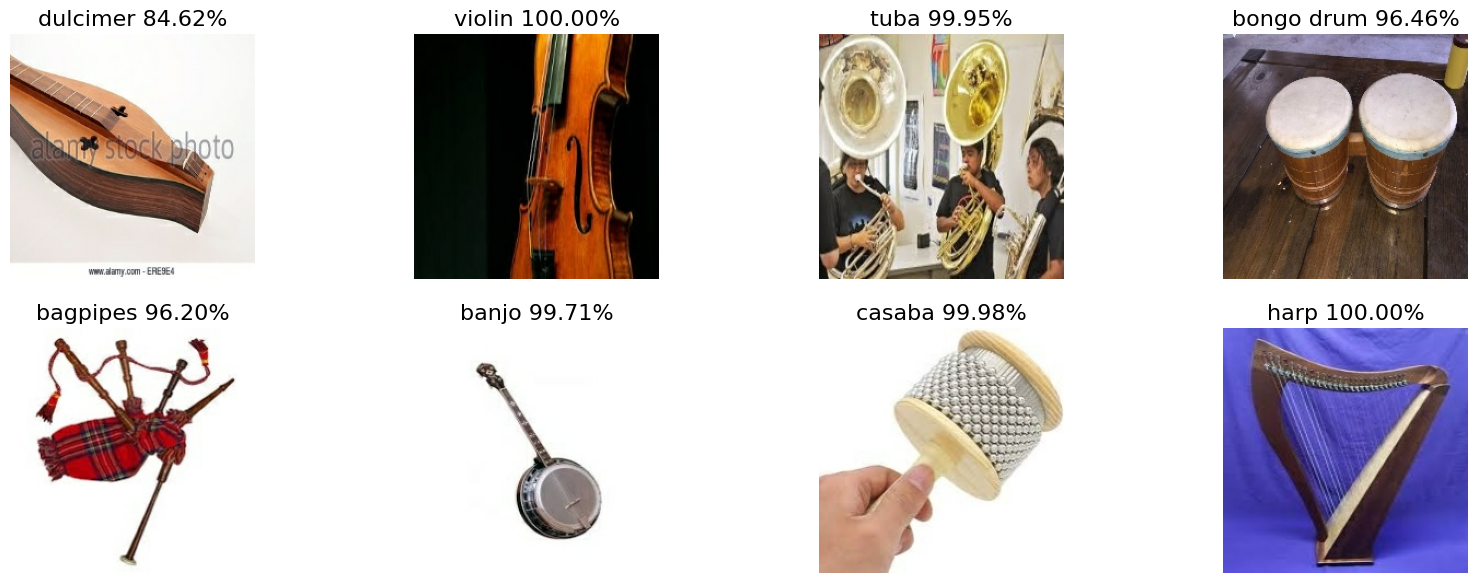

In [37]:
# Get a few sample image paths from the test set
sample_test_image_paths = test_df['path'].sample(n=8, random_state=SEED_VALUE).tolist()

# Use the process_images function to display predictions
# We need the correct preprocessing function and image size for our fine-tuned InceptionV3 model
process_images(
    model=model, # Our fine-tuned model
    image_paths=sample_test_image_paths,
    size=IMAGE_SIZE, # (299, 299)
    preprocess_input=preprocess_input_inception, # InceptionV3 specific preprocessing
    display_top_k=True, # Display top-k predictions
    top_k=3 # Display top 3 predictions
)